# 01 — Time Series Construction
## From Raw Transactions to Daily Demand Per Item

**Purpose.** Transform the raw POS transaction log into a clean, structured time
series suitable for forecasting. Each row in the output will represent one
day × one item, with the quantity sold that day. Days where an item wasn't
sold are filled with zeros (not left as missing — a critical distinction for
time series models).

**Input:** `enterprise_pos_dataset.csv` — ~165,000 line items across 36 months

**Output:** `daily_item_demand.csv` — 1,094 days × 122 items = ~133,000 rows, each
with the quantity sold plus item metadata (section, category, price)

---

## Notebook structure
1. Setup and data loading
2. Data cleaning (remove voids)
3. Daily aggregation per item
4. Fill missing days with zeros (complete grid)
5. Add item metadata
6. Validate the time series
7. Train / Validation / Test split definition
8. Save for downstream notebooks


## 1. Setup and data loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# === ADJUST THIS PATH TO YOUR FOLDER LAYOUT ===
DATASETS_DIR = '../../datasets'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 10

print(f"Working directory: {os.getcwd()}")
print(f"Looking for data in: {os.path.abspath(DATASETS_DIR)}")

Working directory: c:\Users\slimc\Desktop\Notebooks\Module 2\times_series_construction
Looking for data in: c:\Users\slimc\Desktop\Notebooks\datasets


In [2]:
# Load raw transactions
df = pd.read_csv(os.path.join(DATASETS_DIR, 'enterprise_pos_dataset.csv'), sep='|')
df['order_date'] = pd.to_datetime(df['order_date'])

print(f"Raw dataset: {len(df):,} line items")
print(f"Orders:      {df['order_id'].nunique():,}")
print(f"Items:       {df['item_name'].nunique()}")
print(f"Date range:  {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"Total days:  {(df['order_date'].max() - df['order_date'].min()).days + 1}")

Raw dataset: 178,839 line items
Orders:      63,049
Items:       122
Date range:  2023-01-01 → 2025-12-31
Total days:  1096


## 2. Data cleaning

We remove voided orders — they represent cancelled transactions where the
items were never actually consumed. Including them would inflate demand
estimates.

In [3]:
n_before = len(df)
voided_count = df['is_voided'].sum()

df_clean = df[~df['is_voided']].copy()

print(f"Voided line items removed: {voided_count:,}")
print(f"Clean dataset: {len(df_clean):,} line items ({len(df_clean)/n_before*100:.1f}%)")
print(f"Clean orders:  {df_clean['order_id'].nunique():,}")

Voided line items removed: 2,961
Clean dataset: 175,878 line items (98.3%)
Clean orders:  61,986


## 3. Daily aggregation per item

For each (date, item) pair, count how many units were sold. This is the raw
demand signal before filling zeros.

**Important:** we count line items, not orders. If a customer orders 2 Espressos
in the same basket, that's 2 units of demand for Espresso, not 1.

In [4]:
# Aggregate: count units sold per (date, item)
daily_raw = df_clean.groupby(['order_date', 'item_name']).size().reset_index(name='quantity')

print(f"Raw daily aggregation: {len(daily_raw):,} (date, item) pairs")
print(f"Unique dates:  {daily_raw['order_date'].nunique()}")
print(f"Unique items:  {daily_raw['item_name'].nunique()}")
print(f"\nSample:")
daily_raw.head(10)

Raw daily aggregation: 88,868 (date, item) pairs
Unique dates:  1096
Unique items:  122

Sample:


,order_date,item_name,quantity
0,2023-01-01,14oz Ribeye,2
1,2023-01-01,8oz Filet Mignon,5
2,2023-01-01,Acai Berry Bowl,1
3,2023-01-01,Almond Croissant,5
4,2023-01-01,Avocado Toast,2
5,2023-01-01,Bacon Double Burger,6
6,2023-01-01,Beef Lasagna,5
7,2023-01-01,Beef Tacos (3pc),7
8,2023-01-01,Black Tea,2
9,2023-01-01,Blueberry Muffin,4


## 4. Fill missing days with zeros — the complete grid

This is the most critical step. If Crème Brûlée wasn't sold on a Tuesday,
that's **zero demand**, not missing data. Time series models treat NaN and 0
very differently — NaN means "I don't know what happened" while 0 means
"nothing was sold." For demand forecasting, we need explicit zeros.

We create a full grid of (every date × every item) and fill missing pairs
with quantity=0.

In [5]:
# Create the full date range
all_dates = pd.date_range(
    start=df_clean['order_date'].min(),
    end=df_clean['order_date'].max(),
    freq='D'
)

# Create the full item list
all_items = sorted(df_clean['item_name'].unique())

print(f"Date range: {all_dates.min().date()} → {all_dates.max().date()}")
print(f"Total dates: {len(all_dates)}")
print(f"Total items: {len(all_items)}")
print(f"Expected grid size: {len(all_dates)} × {len(all_items)} = {len(all_dates) * len(all_items):,} rows")

Date range: 2023-01-01 → 2025-12-31
Total dates: 1096
Total items: 122
Expected grid size: 1096 × 122 = 133,712 rows


In [6]:
# Build the complete grid using a MultiIndex
from itertools import product

full_grid = pd.DataFrame(
    list(product(all_dates, all_items)),
    columns=['order_date', 'item_name']
)

# Merge with actual sales (left join — grid stays complete, unmatched = NaN)
daily_demand = full_grid.merge(daily_raw, on=['order_date', 'item_name'], how='left')

# Fill NaN with 0 — no sales on that day = zero demand
daily_demand['quantity'] = daily_demand['quantity'].fillna(0).astype(int)

print(f"Complete grid: {len(daily_demand):,} rows")
print(f"Zero-demand entries: {(daily_demand['quantity'] == 0).sum():,} ({(daily_demand['quantity'] == 0).mean()*100:.1f}%)")
print(f"Non-zero entries:    {(daily_demand['quantity'] > 0).sum():,} ({(daily_demand['quantity'] > 0).mean()*100:.1f}%)")

Complete grid: 133,712 rows
Zero-demand entries: 44,844 (33.5%)
Non-zero entries:    88,868 (66.5%)


**Reading the zero-demand percentage.** A high zero rate (>50%) is expected
and normal. Most items don't sell every single day — a Steakhouse dessert
might sell 4 days a week and have 3 zero-days. The forecasting model needs to
learn this sparsity pattern, not ignore it.

## 5. Add item metadata

Attach each item's section (`restaurant_type`), category, and average price.
These become features for the forecasting models — the model should know that
Espresso is a Café/Beverage item priced at $3.00, which behaves differently
from a $35 Filet Mignon in Steakhouse/Main.

In [7]:
# Build item metadata lookup from the original data
item_meta = df_clean.groupby('item_name').agg(
    section=('restaurant_type', 'first'),
    category=('category', 'first'),
    avg_price=('price', 'mean'),
    item_id=('item_id', 'first'),
).reset_index()

print(f"Item metadata: {len(item_meta)} items")
print(f"\nSections: {item_meta['section'].unique().tolist()}")
print(f"Categories: {item_meta['category'].unique().tolist()}")
print(f"\nPrice range: ${item_meta['avg_price'].min():.2f} → ${item_meta['avg_price'].max():.2f}")
item_meta.head(10)

Item metadata: 122 items

Sections: ['Steakhouse', 'Healthy_Vegan', 'Cafe', 'American', 'Italian', 'Mexican', 'Japanese']
Categories: ['Main', 'Food', 'Bakery', 'Dessert', 'Beverage', 'Appetizer', 'Side', 'Alcohol']

Price range: $2.00 → $38.00


,item_name,section,category,avg_price,item_id
0,14oz Ribeye,Steakhouse,Main,32.000000,1
1,8oz Filet Mignon,Steakhouse,Main,34.955183,2
2,Acai Berry Bowl,Healthy_Vegan,Food,9.493237,3
3,Almond Croissant,Cafe,Bakery,4.250000,4
4,Apple Pie,American,Dessert,5.000000,5
5,Avocado Toast,Cafe,Food,7.998151,6
6,Bacon Double Burger,American,Main,11.997912,7
7,Beef Lasagna,Italian,Main,16.984377,8
8,Beef Tacos (3pc),Mexican,Main,11.000000,9
9,Black Tea,Cafe,Beverage,2.500000,10


In [8]:
# Merge metadata into the daily demand table
daily_demand = daily_demand.merge(item_meta, on='item_name', how='left')

print(f"Final shape: {daily_demand.shape}")
print(f"\nColumns: {list(daily_demand.columns)}")
daily_demand.head()

Final shape: (133712, 7)

Columns: ['order_date', 'item_name', 'quantity', 'section', 'category', 'avg_price', 'item_id']


,order_date,item_name,quantity,section,category,avg_price,item_id
0,2023-01-01,14oz Ribeye,2,Steakhouse,Main,32.000000,1
1,2023-01-01,8oz Filet Mignon,5,Steakhouse,Main,34.955183,2
2,2023-01-01,Acai Berry Bowl,1,Healthy_Vegan,Food,9.493237,3
3,2023-01-01,Almond Croissant,5,Cafe,Bakery,4.250000,4
4,2023-01-01,Apple Pie,0,American,Dessert,5.000000,5


## 6. Validate the time series

Before saving, verify the grid is complete and the numbers make sense.

In [9]:
# Completeness check
n_dates = daily_demand['order_date'].nunique()
n_items = daily_demand['item_name'].nunique()
expected = n_dates * n_items
actual = len(daily_demand)

print("=== VALIDATION ===")
print(f"  Dates:    {n_dates}")
print(f"  Items:    {n_items}")
print(f"  Expected: {expected:,}")
print(f"  Actual:   {actual:,}")
print(f"  Match:    {'✓ PASS' if expected == actual else '✗ FAIL'}")
print(f"  Missing:  {daily_demand.isnull().sum().sum()}")

=== VALIDATION ===
  Dates:    1096
  Items:    122
  Expected: 133,712
  Actual:   133,712
  Match:    ✓ PASS
  Missing:  0


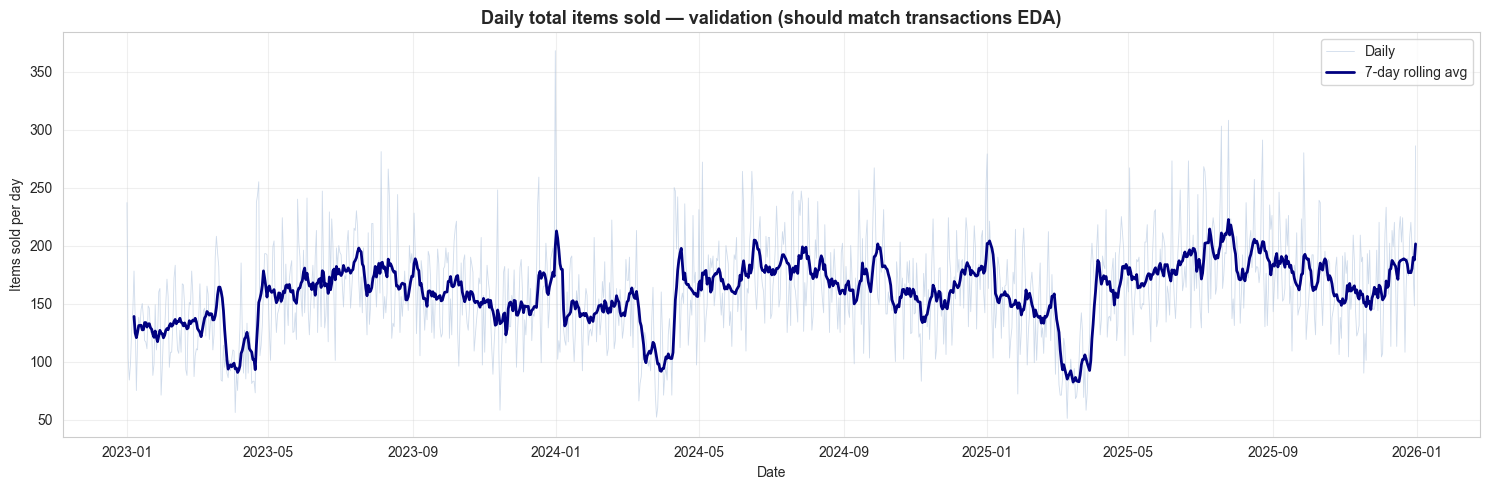


Daily items sold:
  Mean:   160.5
  Min:    51 on 2025-03-10
  Max:    368 on 2023-12-31


In [10]:
# Daily total orders (should match what we saw in EDA)
daily_total = daily_demand.groupby('order_date')['quantity'].sum()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily_total.index, daily_total.values, color='lightsteelblue',
        linewidth=0.6, alpha=0.6, label='Daily')
ax.plot(daily_total.index, daily_total.rolling(7).mean().values,
        color='navy', linewidth=2, label='7-day rolling avg')
ax.set_title('Daily total items sold — validation (should match transactions EDA)')
ax.set_ylabel('Items sold per day')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDaily items sold:")
print(f"  Mean:   {daily_total.mean():.1f}")
print(f"  Min:    {daily_total.min()} on {daily_total.idxmin().date()}")
print(f"  Max:    {daily_total.max()} on {daily_total.idxmax().date()}")

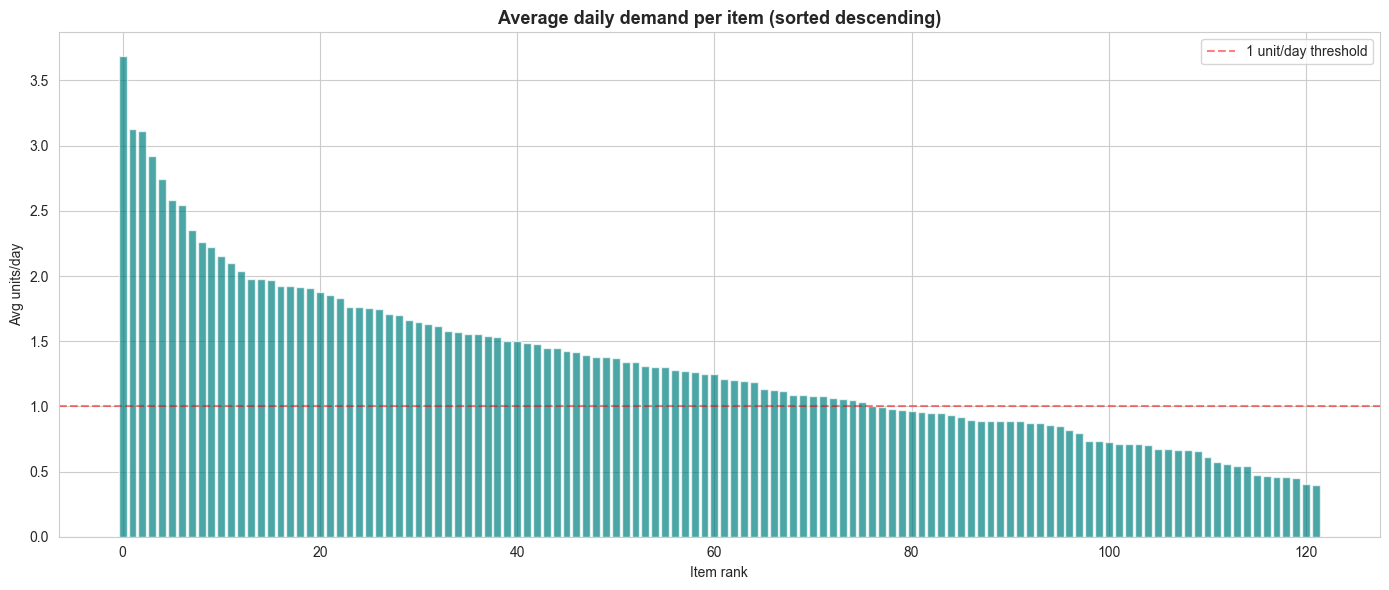


Item volume tiers:
  High (≥5/day):  0 items
  Medium (1-5/day): 77 items
  Low (<1/day):   45 items

Top 10 items by daily demand:
  3.7/day  Hot Dog with Mustard
  3.1/day  Bacon Double Burger
  3.1/day  Chicken Tenders (4pc)
  2.9/day  Spicy BBQ Bacon Burger
  2.7/day  Crispy Chicken Sandwich
  2.6/day  Oatmeal with Berries
  2.5/day  Avocado Toast
  2.4/day  Breakfast Sandwich (Egg & Cheese)
  2.3/day  Philly Cheesesteak
  2.2/day  Salmon Nigiri (2pc)

Bottom 5 items:
  0.5/day  Chocolate Brownie
  0.5/day  Cannoli
  0.5/day  New York Cheesecake
  0.4/day  Vegan Peanut Butter Protein Ball
  0.4/day  Green Tea Mochi Ice Cream


In [11]:
# Per-item demand distribution
item_daily_avg = daily_demand.groupby('item_name')['quantity'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(item_daily_avg)), item_daily_avg.values, color='teal', alpha=0.7)
ax.set_title('Average daily demand per item (sorted descending)')
ax.set_xlabel('Item rank')
ax.set_ylabel('Avg units/day')
ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='1 unit/day threshold')
ax.legend()
plt.tight_layout()
plt.show()

# Count items by volume tier
high = (item_daily_avg >= 5).sum()
mid = ((item_daily_avg >= 1) & (item_daily_avg < 5)).sum()
low = (item_daily_avg < 1).sum()

print(f"\nItem volume tiers:")
print(f"  High (≥5/day):  {high} items")
print(f"  Medium (1-5/day): {mid} items")
print(f"  Low (<1/day):   {low} items")
print(f"\nTop 10 items by daily demand:")
for item, avg in item_daily_avg.head(10).items():
    print(f"  {avg:.1f}/day  {item}")
print(f"\nBottom 5 items:")
for item, avg in item_daily_avg.tail(5).items():
    print(f"  {avg:.1f}/day  {item}")

**Reading.** The long-tail distribution confirms what we expected: a few
high-volume items sell 5+ units daily, many mid-range items sell 1-4, and the
tail sells less than 1 per day. The global forecasting model handles all of
these in a single training pass — high-volume items provide the seasonal
patterns that the model transfers to low-volume items.

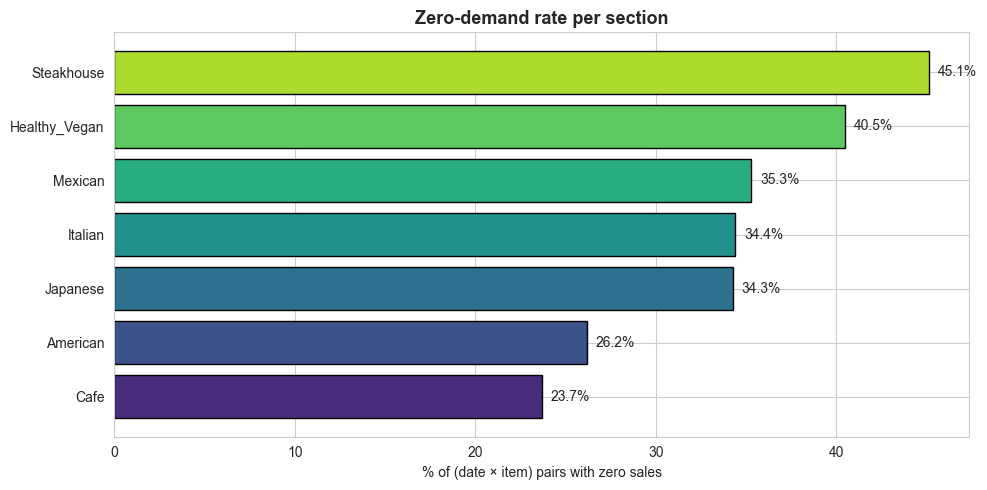

In [12]:
# Sparsity per section
section_sparsity = daily_demand.groupby('section').apply(
    lambda x: (x['quantity'] == 0).mean() * 100
).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(section_sparsity.index, section_sparsity.values,
               color=sns.color_palette('viridis', len(section_sparsity)),
               edgecolor='black')
ax.set_title('Zero-demand rate per section')
ax.set_xlabel('% of (date × item) pairs with zero sales')
for bar, val in zip(bars, section_sparsity.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

**Reading.** Higher sparsity means items in that section sell less
frequently. This is expected for niche sections (Steakhouse, Healthy_Vegan)
with fewer menu items that don't sell daily. The forecasting model needs to
handle zeros gracefully — predicting 0.3 units is valid (it means "this item
sells roughly every 3 days").

## 7. Train / Validation / Test split

Time-series splits must be **chronological** — no random shuffling, no future
data leaking into training.

| Split | Period | Days | Purpose |
|---|---|---|---|
| **Train** | Jan 2023 → Feb 2024 | ~425 days | Learn patterns |
| **Validation** | Mar → Apr 2024 | ~61 days | Tune hyperparameters, includes Ramadan 2024 |
| **Test** | May → Jun 2024 | ~61 days | Final unseen evaluation |

The validation set intentionally includes Ramadan 2024 — this stress-tests
whether the model can handle the biggest structural break in the data.

Chronological split:
        rows  days   date_min   date_max
split                                   
test   33550   275 2025-04-01 2025-12-31
train  89182   731 2023-01-01 2024-12-31
val    10980    90 2025-01-01 2025-03-31


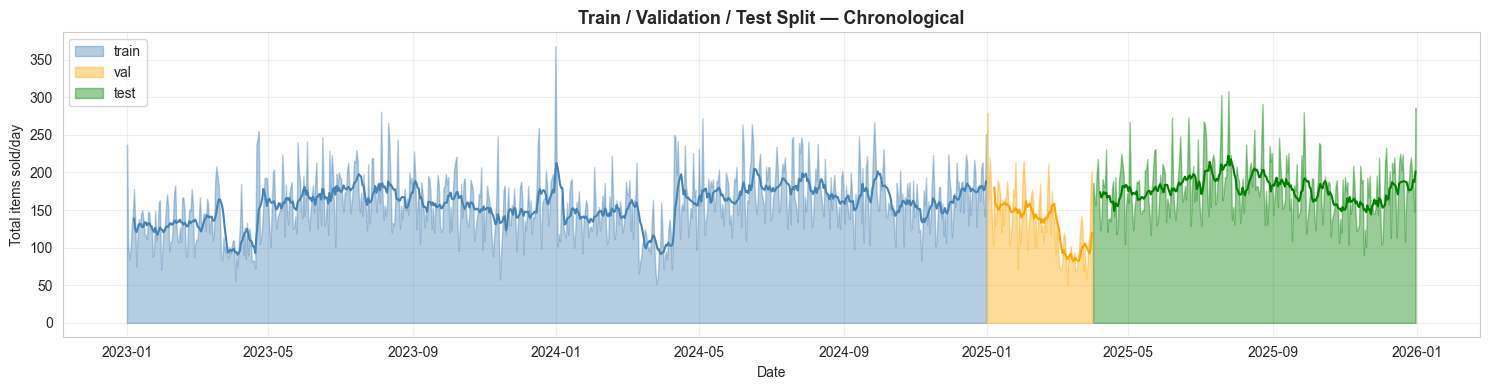

In [13]:
# Define split dates
# v6 split — leverages the extended 36-month dataset
# Train: Jan 2023 → Dec 2024 (covers 2 full Ramadans for fitting)
# Val:   Jan-Mar 2025 (includes 3rd Ramadan as held-out test of the pattern)
# Test:  Apr-Dec 2025 (~9 months: full summer, autumn, NYE)
TRAIN_END = pd.Timestamp('2024-12-31')
VAL_END = pd.Timestamp('2025-03-31')

# Apply splits
daily_demand['split'] = 'train'
daily_demand.loc[daily_demand['order_date'] > TRAIN_END, 'split'] = 'val'
daily_demand.loc[daily_demand['order_date'] > VAL_END, 'split'] = 'test'

split_counts = daily_demand.groupby('split').agg(
    rows=('quantity', 'count'),
    days=('order_date', 'nunique'),
    date_min=('order_date', 'min'),
    date_max=('order_date', 'max'),
)
print("Chronological split:")
print(split_counts)

# Visualize the split
fig, ax = plt.subplots(figsize=(15, 4))
daily_by_split = daily_demand.groupby(['order_date', 'split'])['quantity'].sum().reset_index()
colors = {'train': 'steelblue', 'val': 'orange', 'test': 'green'}
for split in ['train', 'val', 'test']:
    sub = daily_by_split[daily_by_split['split'] == split]
    ax.fill_between(sub['order_date'], sub['quantity'], alpha=0.4, color=colors[split], label=split)
    ax.plot(sub['order_date'], sub['quantity'].rolling(7).mean(), color=colors[split], linewidth=1.5)
ax.set_title('Train / Validation / Test Split — Chronological')
ax.set_ylabel('Total items sold/day')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Save for downstream notebooks

We save the complete daily demand table. Every subsequent notebook (Prophet,
XGBoost, LSTM, etc.) loads this file instead of re-processing from raw
transactions.

In [14]:
# Save
output_path = os.path.join(DATASETS_DIR, 'daily_item_demand.csv')
daily_demand.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")
print(f"Shape: {daily_demand.shape}")
print(f"\nFinal schema:")
print(daily_demand.dtypes)
print(f"\nSample (first item, first 5 days):")
sample_item = daily_demand['item_name'].iloc[0]
daily_demand[daily_demand['item_name'] == sample_item].head()

Saved to: ../../datasets\daily_item_demand.csv
Shape: (133712, 8)

Final schema:
order_date    datetime64[ns]
item_name             object
quantity               int32
section               object
category              object
avg_price            float64
item_id                int64
split                 object
dtype: object

Sample (first item, first 5 days):


,order_date,item_name,quantity,section,category,avg_price,item_id,split
0,2023-01-01,14oz Ribeye,2,Steakhouse,Main,32.0,1,train
122,2023-01-02,14oz Ribeye,0,Steakhouse,Main,32.0,1,train
244,2023-01-03,14oz Ribeye,0,Steakhouse,Main,32.0,1,train
366,2023-01-04,14oz Ribeye,3,Steakhouse,Main,32.0,1,train
488,2023-01-05,14oz Ribeye,0,Steakhouse,Main,32.0,1,train


## 9. Weekly aggregation (for forecasting models)

**Why this section exists:** the daily-aggregated `daily_item_demand.csv` we
just built has 64% of values as 0 or 1 — sparse count data with a high
integer-rounding noise floor. Per-item daily forecasting hits a mathematical
ceiling on this kind of data.

**The fix:** aggregate to weekly granularity for the forecasting models. Weekly
sums collapse the noise floor (CV drops from 0.6-1.5 per item to 0.3-0.7) and
align with how restaurants actually make ordering / staffing decisions
(weekly cycles, not daily).

**Important:** the daily file stays — Module 4 (anomaly detection) needs daily
granularity to catch one-off events. Different problems, different optimal time
scales.

This section produces `weekly_item_demand.csv` for use by all forecasting
notebooks (03 onward).

In [15]:
# Aggregate the *clean* daily_demand grid up to weekly level (ISO week, Monday-start)
# We aggregate from daily_demand (not raw df) so that:
#   - Quantities already include zero-filled days (no silent drops)
#   - Schema is already clean (section/category/avg_price/item_id present)

daily_demand['week_start'] = daily_demand['order_date'].dt.to_period('W-MON').dt.start_time

weekly = daily_demand.groupby(['week_start', 'item_name']).agg(
    quantity=('quantity', 'sum'),
    n_days=('order_date', 'nunique'),
    section=('section', 'first'),
    category=('category', 'first'),
    avg_price=('avg_price', 'mean'),
    item_id=('item_id', 'first'),
).reset_index()

# Drop partial weeks at the edges (keep only full 7-day weeks)
n_before = len(weekly)
weekly = weekly[weekly['n_days'] == 7].drop('n_days', axis=1)
print(f"Dropped {n_before - len(weekly):,} partial-week rows at edges (kept {len(weekly):,} full weeks)")

# Apply chronological split at week granularity (v6)
# Train: through week of Dec 30 2024 (~104 weeks, covers 2 full Ramadans + 2 summers)
# Val:   Jan 6 → Mar 31 2025 (~13 weeks, includes 3rd Ramadan as a held-out test)
# Test:  Apr 7 → Dec 29 2025 (~38 weeks, full summer + autumn + Christmas/NYE)
TRAIN_END_W = pd.Timestamp('2024-12-30')
VAL_END_W = pd.Timestamp('2025-03-31')

weekly['split'] = 'train'
weekly.loc[weekly['week_start'] > TRAIN_END_W, 'split'] = 'val'
weekly.loc[weekly['week_start'] > VAL_END_W, 'split'] = 'test'

# Sanity check: no leakage between splits
train_max = weekly[weekly['split'] == 'train']['week_start'].max()
val_min = weekly[weekly['split'] == 'val']['week_start'].min()
val_max = weekly[weekly['split'] == 'val']['week_start'].max()
test_min = weekly[weekly['split'] == 'test']['week_start'].min()
assert val_min > train_max, "LEAKAGE: val overlaps train!"
assert test_min > val_max, "LEAKAGE: test overlaps val!"
print(f"✓ No temporal leakage between weekly splits")

# Save
weekly_path = os.path.join(DATASETS_DIR, 'weekly_item_demand.csv')
weekly.to_csv(weekly_path, index=False)
print(f"\n✓ Saved: {weekly_path}")
print(f"  Shape: {weekly.shape}")
print(f"  Date range: {weekly['week_start'].min().date()} → {weekly['week_start'].max().date()}")
print(f"  Total weeks: {weekly['week_start'].nunique()}")
print(f"  Items: {weekly['item_name'].nunique()}")

print(f"\nSplit summary:")
split_summary = weekly.groupby('split').agg(
    weeks=('week_start', 'nunique'),
    rows=('quantity', 'count'),
    date_min=('week_start', 'min'),
    date_max=('week_start', 'max'),
    mean_qty=('quantity', 'mean'),
)
print(split_summary.to_string())

Dropped 244 partial-week rows at edges (kept 19,032 full weeks)
✓ No temporal leakage between weekly splits

✓ Saved: ../../datasets\weekly_item_demand.csv
  Shape: (19032, 8)
  Date range: 2023-01-03 → 2025-12-23
  Total weeks: 156
  Items: 122

Split summary:
       weeks   rows   date_min   date_max   mean_qty
split                                               
test      39   4758 2025-04-01 2025-12-23  10.224254
train    104  12688 2023-01-03 2024-12-24   9.000394
val       13   1586 2024-12-31 2025-03-25   7.730139


### Quick sanity check: weekly vs daily distributional shift

The aggregation should reduce sparsity dramatically — from 64% zeros/ones daily
to almost none weekly. Confirming this is what makes weekly forecasting tractable.

In [16]:
# Compare daily vs weekly distributional properties
print("DAILY (per-item per-day):")
print(f"  Mean:   {daily_demand['quantity'].mean():.2f}")
print(f"  Median: {daily_demand['quantity'].median():.0f}")
print(f"  Zeros:  {(daily_demand['quantity']==0).sum():,} ({(daily_demand['quantity']==0).mean()*100:.1f}%)")
print(f"  Ones:   {(daily_demand['quantity']==1).sum():,} ({(daily_demand['quantity']==1).mean()*100:.1f}%)")
print(f"  Max:    {daily_demand['quantity'].max()}")

print(f"\nWEEKLY (per-item per-week):")
print(f"  Mean:   {weekly['quantity'].mean():.2f}")
print(f"  Median: {weekly['quantity'].median():.0f}")
print(f"  Zeros:  {(weekly['quantity']==0).sum():,} ({(weekly['quantity']==0).mean()*100:.1f}%)")
print(f"  Ones:   {(weekly['quantity']==1).sum():,} ({(weekly['quantity']==1).mean()*100:.1f}%)")
print(f"  Max:    {weekly['quantity'].max()}")

# CV comparison — predictability metric
daily_cv = daily_demand.groupby('item_name')['quantity'].agg(
    lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan
).median()
weekly_cv = weekly.groupby('item_name')['quantity'].agg(
    lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan
).median()
print(f"\nMedian per-item CV (lower = more predictable):")
print(f"  Daily:  {daily_cv:.3f}")
print(f"  Weekly: {weekly_cv:.3f}")
print(f"  → Reduction: {(1 - weekly_cv/daily_cv)*100:.0f}% lower noise on weekly aggregation")

DAILY (per-item per-day):
  Mean:   1.32
  Median: 1
  Zeros:  44,844 (33.5%)
  Ones:   41,427 (31.0%)
  Max:    16

WEEKLY (per-item per-week):
  Mean:   9.20
  Median: 8
  Zeros:  127 (0.7%)
  Ones:   488 (2.6%)
  Max:    43

Median per-item CV (lower = more predictable):
  Daily:  0.961
  Weekly: 0.419
  → Reduction: 56% lower noise on weekly aggregation


## Summary

This notebook produced two output files in `datasets/`:

1. **`daily_item_demand.csv`** — daily granularity, 122 items × 1,094 days
   - Used by Module 4 (anomaly detection — needs daily resolution to catch one-off events)
   - Used by notebook 02 (EDA — daily patterns inform both daily and weekly modeling)

2. **`weekly_item_demand.csv`** — weekly granularity (NEW), 122 items × ~156 weeks
   - Used by all Module 2 forecasting notebooks (03 onward)
   - Aligns with how restaurants make ordering / staffing decisions
   - Reduces noise floor that bottlenecked daily forecasting

Both files share the same chronological train / val / test split structure,
just at different time resolutions.

**Next:** notebook 02 (EDA — kept at daily granularity since the underlying
patterns inform both modeling tracks).